In [7]:
import os, sys
project_root = os.path.abspath('..').replace('\\', '/')
if project_root not in [p.replace('\\', '/') for p in sys.path]:
    sys.path.append(project_root)

# 06 EDA探索性数据分析模块 (core.eda)

提供金融风控场景下的完整数据探索功能。

**数据说明**: 基于 `hscredit_yyp.xlsx`

In [8]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
import hscredit.core.eda as eda

init_setting()

# 加载数据
_roots = [Path.cwd(), Path.cwd() / 'examples', Path.cwd().parent]
_fp = None
for _r in _roots:
    for _n in ('hscredit_yyp.xlsx', 'hengshucredit_yyp.xlsx'):
        if (_r / _n).is_file():
            _fp = _r / _n
            break
    if _fp is not None:
        break
if _fp is None:
    raise FileNotFoundError('请将 hscredit_yyp.xlsx 放在 examples/')

df = pd.read_excel(_fp)

# 构造目标变量
df['target'] = (df['MOB1'] > 3).astype(int)

# 提取月份
df['放款月份'] = pd.to_datetime(df['放款时间']).dt.to_period('M').astype(str)

print(f"样本数: {len(df):,}")
print(f"时间范围: {df['放款时间'].min()} ~ {df['放款时间'].max()}")
print(f"坏样本率: {df['target'].mean():.2%}")

样本数: 970
时间范围: 2025-11-06 00:00:00 ~ 2026-02-25 00:00:00
坏样本率: 16.70%


## 1. 数据概览

In [9]:
# 数据基本信息
print("=== 数据概览 ===")
data_info = eda.data_info(df)
display(data_info)

=== 数据概览 ===


,信息项,值
0,样本数（行）,970.0000
1,特征数（列）,20.0000
2,数值型特征,14.0000
3,分类型特征,1.0000
4,日期型特征,2.0000
5,常数特征,0.0000
6,ID特征,3.0000
7,缺失值列数,5.0000
8,总缺失值数,2068.0000
9,内存使用(MB),0.2900


In [10]:
# 缺失分析
print("\n=== 缺失分析 ===")
missing_analysis = eda.missing_analysis(df)
display(missing_analysis[missing_analysis['缺失数'] > 0])


=== 缺失分析 ===


,特征名,缺失数,缺失率(%),非空数,查得率(%)
0,珊瑚92,706,72.7800,264,27.2200
1,中智小牛分C3,663,68.3500,307,31.6500
2,极光欺诈分6v1,662,68.2500,308,31.7500
3,轻花老客海纳子分V1,32,3.3000,938,96.7000
4,占信V3,5,0.5200,965,99.4800


## 2. 目标变量分析

=== 目标变量分布 ===


,类别,样本数,占比(%),累计占比(%)
0,0,808,83.3000,83.3000
1,1,162,16.7000,100.0000


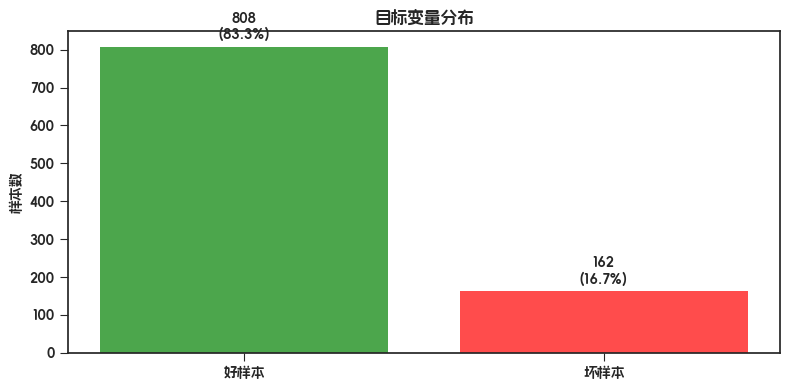

In [11]:
# 目标变量分布
print("=== 目标变量分布 ===")
target_dist = eda.target_distribution(df, target_col='target')
display(target_dist)

plt.figure(figsize=(8, 4))
counts = df['target'].value_counts()
plt.bar(['好样本', '坏样本'], counts.values, color=['green', 'red'], alpha=0.7)
plt.ylabel('样本数')
plt.title('目标变量分布')
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, f'{v:,}\n({v/len(df):.1%})', ha='center')
plt.tight_layout()
plt.show()


=== 逾期率趋势 ===


,时间周期,样本数,好样本数,坏样本数,逾期率(%),环比变化(%)
0,2025-11,356,304,52,14.6100,NaN
1,2025-12,281,240,41,14.5900,-0.0200
2,2026-01,152,124,28,18.4200,3.8300
3,2026-02,181,166,15,8.2900,-10.1300


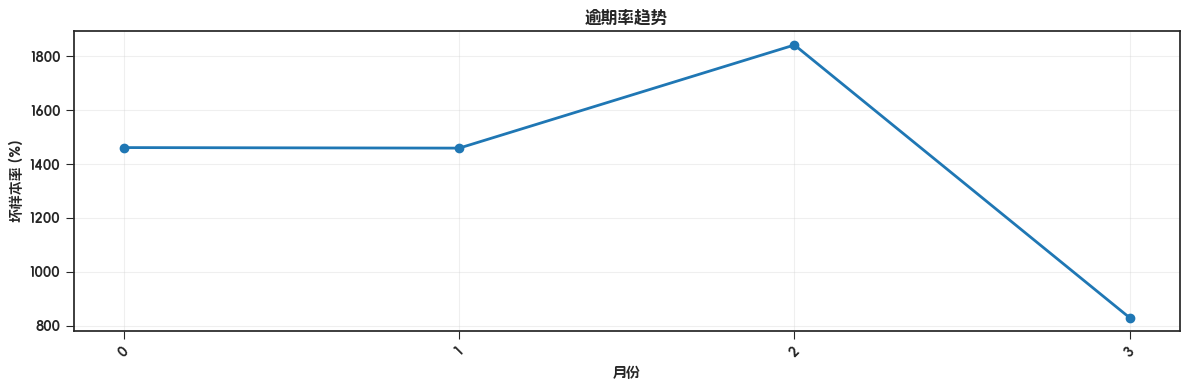

In [12]:
# 逾期率趋势（按月）
print("\n=== 逾期率趋势 ===")
bad_rate_trend = eda.bad_rate_trend(df, target_col='FPD', date_col='放款月份')
display(bad_rate_trend)

plt.figure(figsize=(12, 4))
plt.plot(range(len(bad_rate_trend)), bad_rate_trend['逾期率(%)'] * 100, 'o-', linewidth=2)
plt.xlabel('月份')
plt.ylabel('坏样本率 (%)')
plt.title('逾期率趋势')
plt.xticks(range(len(bad_rate_trend)), bad_rate_trend.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 特征分析

=== 中智小牛分C3 分布 ===


,分箱编号,分箱区间,频数,频率(%),累计频率(%)
0,1,"[464.00, 483.30)",6,1.9500,1.9500
1,2,"[483.30, 502.60)",14,4.5600,6.5100
2,3,"[502.60, 521.90)",14,4.5600,11.0700
3,4,"[521.90, 541.20)",17,5.5400,16.6100
4,5,"[541.20, 560.50)",23,7.4900,24.1000
5,6,"[560.50, 579.80)",19,6.1900,30.2900
6,7,"[579.80, 599.10)",27,8.7900,39.0900
7,8,"[599.10, 618.40)",24,7.8200,46.9100
8,9,"[618.40, 637.70)",18,5.8600,52.7700
9,10,"[637.70, 657.00)",19,6.1900,58.9600


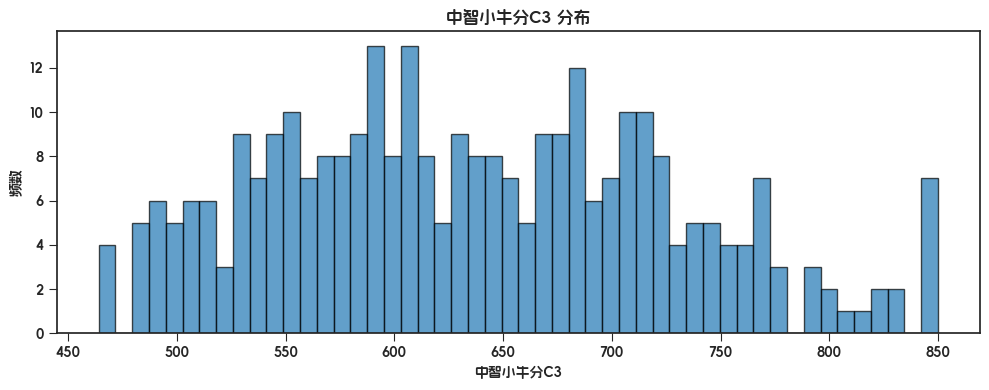

In [13]:
# 数值特征分布
print("=== 中智小牛分C3 分布 ===")
numeric_dist = eda.numeric_distribution(df, feature='中智小牛分C3')
display(numeric_dist)

plt.figure(figsize=(10, 4))
plt.hist(df['中智小牛分C3'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('中智小牛分C3')
plt.ylabel('频数')
plt.title('中智小牛分C3 分布')
plt.tight_layout()
plt.show()

## 4. 特征-标签关系分析

=== 批量IV分析 ===


,特征名,IV值,预测能力,分箱数
0,极光欺诈分6v1,1.9172,极强(需检查),10
1,中智小牛分C3,1.7110,极强(需检查),10
2,珊瑚92,0.3650,强预测能力,10
3,占信V3,0.1635,中等预测能力,10
4,青云24,0.0834,弱预测能力,7


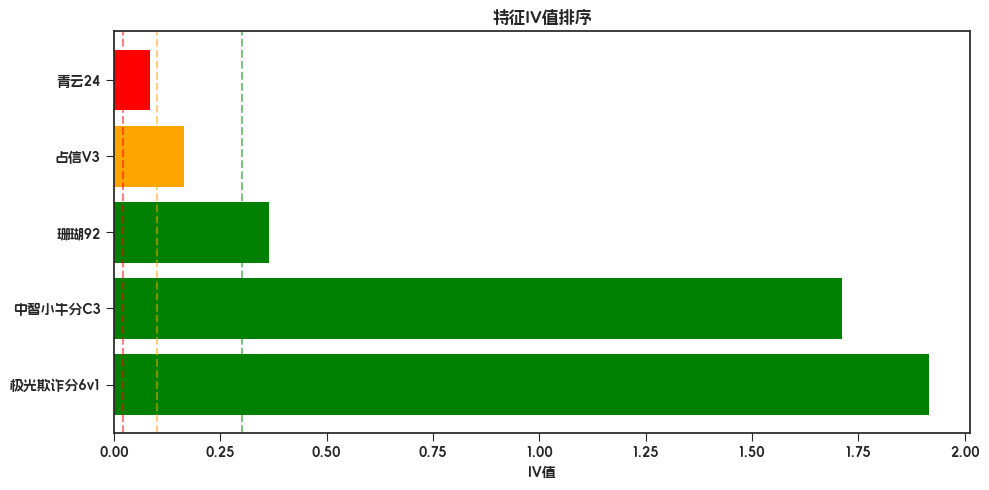

In [14]:
# 批量IV分析
features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3']
batch_iv = eda.batch_iv_analysis(df, features=features, target='target', n_bins=10)

print("=== 批量IV分析 ===")
display(batch_iv)

plt.figure(figsize=(10, 5))
colors = ['green' if iv > 0.3 else 'orange' if iv > 0.1 else 'red' if iv > 0.02 else 'gray' 
          for iv in batch_iv['IV值']]
plt.barh(batch_iv['特征名'], batch_iv['IV值'], color=colors)
plt.axvline(x=0.02, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='green', linestyle='--', alpha=0.5)
plt.xlabel('IV值')
plt.title('特征IV值排序')
plt.tight_layout()
plt.show()

## 5. 相关性分析

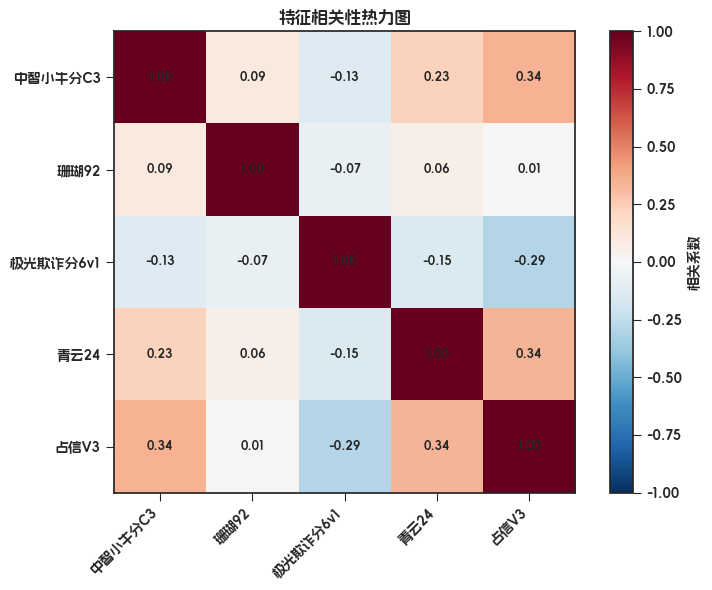

In [15]:
# 相关性矩阵
corr_features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3']
corr_matrix = eda.correlation_matrix(df[corr_features])

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='相关系数')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('特征相关性热力图')
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()